# Clasificación supervisada con Bank Marketing

En esta unidad estudiaremos un problema clásico de **clasificación supervisada** usando Python, pandas y scikit-learn. Trabajaremos con el dataset **Bank Marketing** de UCI, cuyo objetivo es predecir si una persona aceptará o no una oferta de depósito a plazo después de una campaña de marketing telefónico.

La idea central es aprender un modelo a partir de ejemplos históricos. Cada fila del dataset contiene información conocida de una persona y de la campaña; la respuesta `y` indica si esa persona contrató el producto (`yes`) o no (`no`). Como la respuesta tiene dos clases posibles, este es un problema de **clasificación binaria**.

## 1. Introducción

En aprendizaje supervisado tenemos datos de entrada y una respuesta conocida. El modelo observa muchos pares del tipo:

$$\text{entradas} \rightarrow \text{respuesta conocida}$$

Luego intenta aprender una regla que permita estimar la respuesta para casos nuevos.

La diferencia entre **clasificación** y **regresión** está en el tipo de respuesta que queremos predecir:

- En **regresión**, la salida es numérica continua. Por ejemplo: predecir el precio de una vivienda.
- En **clasificación**, la salida es una categoría. Por ejemplo: predecir si un correo es spam o no spam.

En el caso del banco, no queremos predecir un monto continuo. Queremos responder una pregunta de tipo sí/no: **¿esta persona aceptará el producto?**

## 2. Definición del problema

Formalmente, nuestro problema queda definido así:

- **Entrada**: variables sobre la persona, su historial y el contacto realizado por el banco.
- **Salida**: la variable objetivo `y`.
- **Clase positiva**: `yes`, es decir, la persona contrató el depósito a plazo.
- **Clase negativa**: `no`, es decir, la persona no contrató el producto.

Como la variable objetivo solo tiene dos valores posibles, trabajaremos con **clasificación binaria**. En código convertiremos `yes` a `1` y `no` a `0`, porque muchas métricas y modelos esperan etiquetas numéricas.

## 3. Dataset

Usaremos el dataset **Bank Marketing** del repositorio UCI Machine Learning Repository. Este dataset contiene registros de campañas de marketing directo de una institución bancaria portuguesa.

El dataset mezcla distintos tipos de variables:

- **Variables numéricas**: por ejemplo edad, balance o cantidad de contactos previos.
- **Variables categóricas**: por ejemplo trabajo, estado civil, educación o tipo de contacto.
- **Variable objetivo**: `y`, que indica si la persona contrató el depósito a plazo.

Una advertencia importante: la variable `duration` mide cuánto duró la llamada. Esa información solo se conoce después de realizar el contacto, por lo que usarla para predecir antes de llamar produciría **data leakage**. La eliminaremos antes de entrenar los modelos.

## 4. Carga del dataset

Primero importamos las bibliotecas necesarias. Si `ucimlrepo` no está instalado en el entorno, la celda intenta instalarlo usando `%pip install ucimlrepo`. En el repositorio también declaramos esta dependencia en `pyproject.toml`, por lo que en el Dev Container debería estar disponible después de sincronizar el entorno.

In [ ]:
import importlib.util

if importlib.util.find_spec("ucimlrepo") is None:
    print("Instalando ucimlrepo en el kernel actual...")
    %pip install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from ucimlrepo import fetch_ucirepo

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
plt.style.use("default")
pd.set_option("display.max_columns", 80)

In [ ]:
bank_marketing = fetch_ucirepo(id=222)

X_original = bank_marketing.data.features.copy()
y_original = bank_marketing.data.targets.copy()

df = pd.concat([X_original, y_original], axis=1)
variable_objetivo = y_original.columns[0]

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
print(f"Variable objetivo: {variable_objetivo}")

Filas: 45,211
Columnas: 17
Variable objetivo: y


In [ ]:
metadata_variables = bank_marketing.variables
display(metadata_variables)

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,NaN,NaN,no
1,job,Feature,Categorical,Occupation,"type of job (categorical: 'admin.','blue-colla...",NaN,no
2,marital,Feature,Categorical,Marital Status,"marital status (categorical: 'divorced','marri...",NaN,no
3,education,Feature,Categorical,Education Level,"(categorical: 'basic.4y','basic.6y','basic.9y'...",NaN,no
4,default,Feature,Binary,NaN,has credit in default?,NaN,no
5,balance,Feature,Integer,NaN,average yearly balance,euros,no
6,housing,Feature,Binary,NaN,has housing loan?,NaN,no
7,loan,Feature,Binary,NaN,has personal loan?,NaN,no
8,contact,Feature,Categorical,NaN,contact communication type (categorical: 'cell...,NaN,yes
9,day_of_week,Feature,Date,NaN,last contact day of the week,NaN,no


## 5. Inspección inicial

Antes de entrenar modelos, conviene mirar los datos con calma. En esta etapa buscamos responder preguntas simples:

- ¿Cómo se ven las primeras filas?
- ¿Qué tipos de datos tiene cada columna?
- ¿Hay clases desbalanceadas?
- ¿Hay valores faltantes o duplicados?

Estas preguntas parecen básicas, pero evitan muchos errores posteriores.

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
 16  y            45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,44923,11,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,43354,3,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,32191,2,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [ ]:
conteo_clases = df[variable_objetivo].value_counts(dropna=False)
proporcion_clases = df[variable_objetivo].value_counts(normalize=True, dropna=False)

resumen_clases = pd.DataFrame({
    "n": conteo_clases,
    "proporción": proporcion_clases,
})
display(resumen_clases)

,n,proporción
y,,
no,39922,0.883015
yes,5289,0.116985


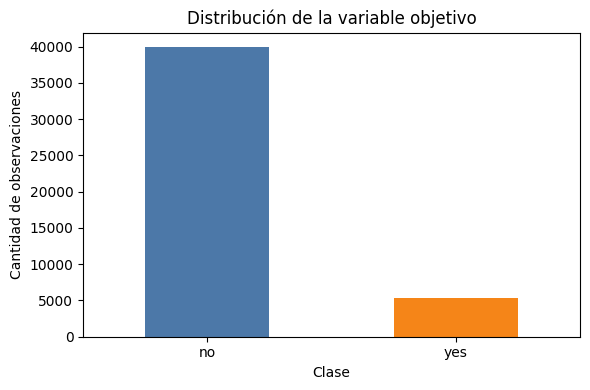

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
resumen_clases["n"].plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518"])
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de observaciones")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
valores_faltantes = df.isna().sum().sort_values(ascending=False)
valores_faltantes = valores_faltantes[valores_faltantes > 0]

print(f"Columnas con valores faltantes reales: {len(valores_faltantes)}")
display(valores_faltantes.to_frame("faltantes"))

duplicados = df.duplicated().sum()
print(f"Filas duplicadas exactas: {duplicados:,}")

Columnas con valores faltantes reales: 4


,faltantes
poutcome,36959
contact,13020
education,1857
job,288


Filas duplicadas exactas: 0


## 6. Preparación de datos

La preparación tiene varios pasos. Primero hacemos una limpieza básica. Luego separamos entradas (`X`) y salida (`y`). Después eliminamos `duration` para evitar data leakage.

También necesitamos tratar de forma distinta las variables numéricas y categóricas:

- A las variables numéricas les aplicaremos imputación y escalamiento.
- A las variables categóricas les aplicaremos imputación y one-hot encoding.

Todo esto se integrará más adelante dentro de un `Pipeline`, para que el mismo proceso se use durante entrenamiento y evaluación.

In [ ]:
df_limpio = df.copy()

columnas_texto = df_limpio.select_dtypes(include="object").columns
for columna in columnas_texto:
    df_limpio[columna] = df_limpio[columna].astype("object").map(
        lambda valor: valor.strip().lower() if isinstance(valor, str) else valor
    )

df_limpio = df_limpio.replace({"unknown": np.nan, "": np.nan})
filas_antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)
filas_despues = len(df_limpio)

print(f"Filas antes de eliminar duplicados exactos: {filas_antes:,}")
print(f"Filas después de eliminar duplicados exactos: {filas_despues:,}")
print(f"Filas eliminadas: {filas_antes - filas_despues:,}")

Filas antes de eliminar duplicados exactos: 45,211
Filas después de eliminar duplicados exactos: 45,211
Filas eliminadas: 0


/var/folders/n4/j3zj6_r13rv55gc2c5btztph0000gn/T/ipykernel_30646/2586486750.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = df_limpio.select_dtypes(include="object").columns


In [ ]:
mapeo_objetivo = {"no": 0, "yes": 1}
y = df_limpio[variable_objetivo].map(mapeo_objetivo).astype(int)
X = df_limpio.drop(columns=[variable_objetivo])

if "duration" in X.columns:
    X = X.drop(columns=["duration"])
    print("Se eliminó la columna 'duration' para evitar data leakage.")
else:
    print("No se encontró la columna 'duration'.")

variables_numericas = X.select_dtypes(include=["number"]).columns.tolist()
variables_categoricas = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Variables numéricas ({len(variables_numericas)}): {variables_numericas}")
print(f"Variables categóricas ({len(variables_categoricas)}): {variables_categoricas}")

Se eliminó la columna 'duration' para evitar data leakage.
Variables numéricas (6): ['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous']
Variables categóricas (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## 7. División del dataset

Separaremos los datos en tres subconjuntos:

- **Train (60%)**: se usa para ajustar los modelos y hacer validación cruzada.
- **Validation (20%)**: se usa para comparar modelos entrenados.
- **Test (20%)**: se reserva hasta el final para estimar desempeño en datos no usados durante la selección.

Usaremos `stratify` para conservar una proporción similar de clases en cada subconjunto. Esto es importante cuando una clase es mucho menos frecuente que la otra.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

resumen_split = pd.DataFrame({
    "filas": [len(X_train), len(X_val), len(X_test)],
    "proporción": [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
    "tasa_clase_positiva": [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=["train", "validation", "test"])

display(resumen_split)

,filas,proporción,tasa_clase_positiva
train,27126,0.599987,0.116973
validation,9042,0.199996,0.117010
test,9043,0.200018,0.116997


## 8. Modelos

Entrenaremos tres modelos:

- **DummyClassifier**: baseline simple. Sirve para saber si un modelo real está aportando valor.
- **LogisticRegression**: modelo lineal clásico para clasificación binaria.
- **RandomForestClassifier**: ensamble de árboles de decisión, capaz de capturar relaciones no lineales.

El baseline es importante porque un dataset desbalanceado puede producir una accuracy alta incluso con un modelo poco útil. Si la mayoría de las personas responde `no`, un modelo que siempre predice `no` puede parecer bueno por accuracy, aunque no detecte clientes interesados.

In [ ]:
preprocesamiento_numerico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalamiento", StandardScaler()),
])

preprocesamiento_categorico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", preprocesamiento_numerico, variables_numericas),
        ("cat", preprocesamiento_categorico, variables_categoricas),
    ]
)

## 9. Entrenamiento con Pipeline, GridSearchCV y StratifiedKFold

`Pipeline` nos permite unir preparación de datos y modelo en un solo objeto. Esto reduce errores, porque evita preparar train y test de formas distintas.

`GridSearchCV` prueba combinaciones de hiperparámetros. Usaremos `StratifiedKFold` para que cada partición de validación cruzada conserve la proporción de clases. Como criterio de búsqueda usaremos `average_precision`, una métrica útil cuando la clase positiva es menos frecuente.

In [ ]:
modelos = {
    "dummy": {
        "estimador": DummyClassifier(random_state=RANDOM_STATE),
        "parametros": {
            "modelo__strategy": ["most_frequent", "stratified"],
        },
    },
    "regresión_logística": {
        "estimador": LogisticRegression(
            max_iter=1000,
            solver="liblinear",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "parametros": {
            "modelo__C": [0.1, 1.0, 10.0],
        },
    },
    "random_forest": {
        "estimador": RandomForestClassifier(
            n_estimators=120,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "parametros": {
            "modelo__max_depth": [8, None],
            "modelo__min_samples_leaf": [1, 5],
        },
    },
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
def construir_pipeline(estimador):
    return Pipeline(steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", estimador),
    ])


def obtener_scores_positivos(modelo_entrenado, X_datos):
    indice_clase_positiva = list(modelo_entrenado.classes_).index(1)
    return modelo_entrenado.predict_proba(X_datos)[:, indice_clase_positiva]


def calcular_metricas(nombre, modelo_entrenado, X_datos, y_real, threshold=0.5):
    scores = obtener_scores_positivos(modelo_entrenado, X_datos)
    y_pred = (scores >= threshold).astype(int)
    return {
        "modelo": nombre,
        "threshold": threshold,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1": f1_score(y_real, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_real, scores),
        "average_precision": average_precision_score(y_real, scores),
    }

In [ ]:
busquedas = {}
mejores_modelos = {}

for nombre, configuracion in modelos.items():
    print(f"Entrenando {nombre}...")
    pipeline = construir_pipeline(configuracion["estimador"])
    busqueda = GridSearchCV(
        estimator=pipeline,
        param_grid=configuracion["parametros"],
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    busqueda.fit(X_train, y_train)
    busquedas[nombre] = busqueda
    mejores_modelos[nombre] = busqueda.best_estimator_
    print(f"  Mejor average precision CV: {busqueda.best_score_:.3f}")
    print(f"  Mejores parámetros: {busqueda.best_params_}")

Entrenando dummy...


  Mejor average precision CV: 0.117
  Mejores parámetros: {'modelo__strategy': 'most_frequent'}
Entrenando regresión_logística...


  Mejor average precision CV: 0.373
  Mejores parámetros: {'modelo__C': 0.1}
Entrenando random_forest...


  Mejor average precision CV: 0.400
  Mejores parámetros: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 5}


## 10. Métricas de evaluación

La **matriz de confusión** separa las predicciones en cuatro casos:

- **TP**: verdaderos positivos. El modelo predijo `yes` y la respuesta real era `yes`.
- **TN**: verdaderos negativos. El modelo predijo `no` y la respuesta real era `no`.
- **FP**: falsos positivos. El modelo predijo `yes`, pero la respuesta real era `no`.
- **FN**: falsos negativos. El modelo predijo `no`, pero la respuesta real era `yes`.

Las métricas principales son:

$$\text{Accuracy} = \frac{TP + TN}{TP + FP + FN + TN}$$

$$\text{Precisión} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN}$$

$$\text{F1} = 2 \cdot \frac{\text{Precisión} \cdot \text{Recall}}{\text{Precisión} + \text{Recall}}$$

También usaremos **ROC AUC** y **Average Precision**. Estas métricas trabajan con scores o probabilidades, no solo con una clase final. Por eso son útiles para comparar modelos antes de elegir un umbral de decisión.

## 11. Evaluación en validation

Ahora evaluamos los mejores modelos encontrados por `GridSearchCV` usando el conjunto de validación. En esta primera comparación usamos el umbral clásico `0.5`: si la probabilidad estimada de `yes` es al menos 0.5, predecimos clase positiva.

In [ ]:
metricas_validacion = [
    calcular_metricas(nombre, modelo, X_val, y_val, threshold=0.5)
    for nombre, modelo in mejores_modelos.items()
]

tabla_validacion = (
    pd.DataFrame(metricas_validacion)
    .set_index("modelo")
    .sort_values("average_precision", ascending=False)
)

display(tabla_validacion.style.format("{:.3f}"))

,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
modelo,,,,,,,
random_forest,0.500,0.867,0.439,0.494,0.465,0.781,0.435
regresión_logística,0.500,0.759,0.263,0.590,0.364,0.748,0.387
dummy,0.500,0.883,0.000,0.000,0.000,0.500,0.117


In [ ]:
criterio_seleccion = "average_precision"
nombre_mejor_modelo = tabla_validacion[criterio_seleccion].idxmax()
mejor_modelo = mejores_modelos[nombre_mejor_modelo]

print(f"Mejor modelo según {criterio_seleccion}: {nombre_mejor_modelo}")
print("Parámetros seleccionados:")
print(busquedas[nombre_mejor_modelo].best_params_)

Mejor modelo según average_precision: random_forest
Parámetros seleccionados:
{'modelo__max_depth': None, 'modelo__min_samples_leaf': 5}


              precision    recall  f1-score   support

          no       0.93      0.92      0.92      7984
         yes       0.44      0.49      0.47      1058

    accuracy                           0.87      9042
   macro avg       0.69      0.71      0.69      9042
weighted avg       0.87      0.87      0.87      9042



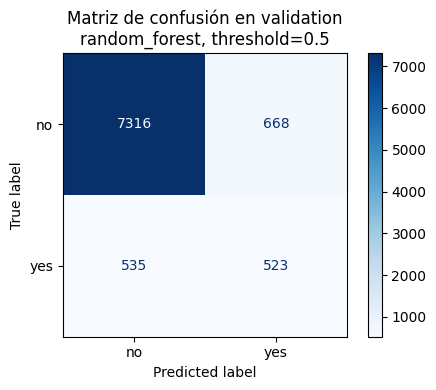

In [ ]:
scores_val = obtener_scores_positivos(mejor_modelo, X_val)
pred_val_05 = (scores_val >= 0.5).astype(int)

print(classification_report(y_val, pred_val_05, target_names=["no", "yes"], zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    pred_val_05,
    display_labels=["no", "yes"],
    cmap="Blues",
    values_format="d",
    ax=ax,
)
ax.set_title(f"Matriz de confusión en validation\n{nombre_mejor_modelo}, threshold=0.5")
plt.tight_layout()
plt.show()

## 12. Threshold tuning

Muchos clasificadores no producen directamente una decisión, sino un **score** o una probabilidad. El **threshold** es el punto de corte que transforma esa probabilidad en una clase.

Con threshold `0.5`, una observación se clasifica como `yes` si su probabilidad estimada es al menos 50%. Pero ese valor no siempre es el mejor. Si bajamos el threshold, el modelo predice más positivos: suele subir el recall, pero puede bajar la precisión. Si subimos el threshold, el modelo exige más evidencia para predecir `yes`: suele subir la precisión, pero puede bajar el recall.

Aquí buscaremos el threshold que maximiza F1 en el conjunto de validación.

In [ ]:
precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, scores_val)

precision_threshold = precision_curve[:-1]
recall_threshold = recall_curve[:-1]
f1_threshold = 2 * (precision_threshold * recall_threshold) / (
    precision_threshold + recall_threshold + 1e-12
)

indice_mejor_threshold = int(np.nanargmax(f1_threshold))
threshold_optimo = float(thresholds[indice_mejor_threshold])

print(f"Threshold que maximiza F1 en validación: {threshold_optimo:.3f}")
print(f"Precisión: {precision_threshold[indice_mejor_threshold]:.3f}")
print(f"Recall: {recall_threshold[indice_mejor_threshold]:.3f}")
print(f"F1: {f1_threshold[indice_mejor_threshold]:.3f}")

Threshold que maximiza F1 en validación: 0.505
Precisión: 0.445
Recall: 0.492
F1: 0.467


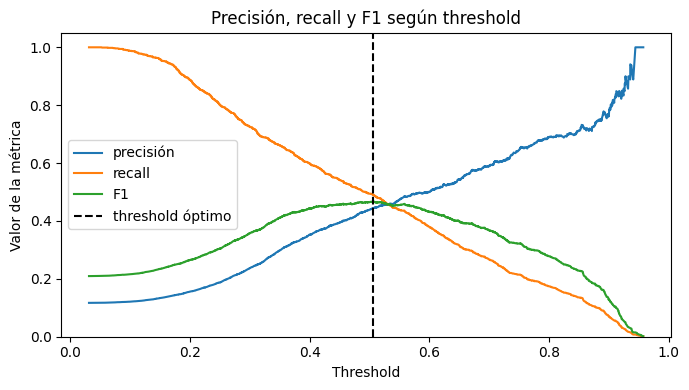

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, precision_threshold, label="precisión")
ax.plot(thresholds, recall_threshold, label="recall")
ax.plot(thresholds, f1_threshold, label="F1")
ax.axvline(threshold_optimo, color="black", linestyle="--", label="threshold óptimo")
ax.set_title("Precisión, recall y F1 según threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Valor de la métrica")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## 13. Evaluación final en test

El conjunto de test se usa una sola vez al final. Esto nos da una estimación más honesta del desempeño esperado, porque test no participó en el entrenamiento, en la búsqueda de hiperparámetros ni en la selección del threshold.

Compararemos el mejor modelo con threshold `0.5` y con el threshold ajustado en validación.

In [ ]:
metricas_test_05 = calcular_metricas(
    f"{nombre_mejor_modelo}_threshold_0.5",
    mejor_modelo,
    X_test,
    y_test,
    threshold=0.5,
)

metricas_test_optimo = calcular_metricas(
    f"{nombre_mejor_modelo}_threshold_ajustado",
    mejor_modelo,
    X_test,
    y_test,
    threshold=threshold_optimo,
)

tabla_test = pd.DataFrame([metricas_test_05, metricas_test_optimo]).set_index("modelo")
display(tabla_test.style.format("{:.3f}"))

,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
modelo,,,,,,,
random_forest_threshold_0.5,0.500,0.872,0.459,0.524,0.489,0.790,0.466
random_forest_threshold_ajustado,0.505,0.873,0.461,0.515,0.487,0.790,0.466


              precision    recall  f1-score   support

          no       0.93      0.92      0.93      7985
         yes       0.46      0.52      0.49      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.72      0.71      9043
weighted avg       0.88      0.87      0.88      9043



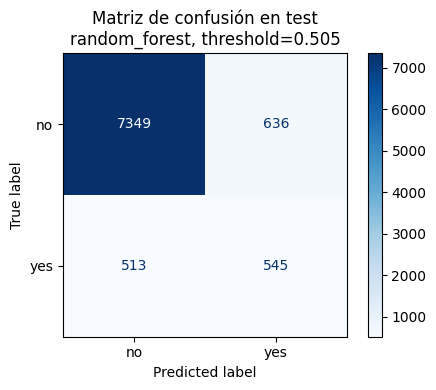

In [ ]:
scores_test = obtener_scores_positivos(mejor_modelo, X_test)
pred_test_optimo = (scores_test >= threshold_optimo).astype(int)

print(classification_report(y_test, pred_test_optimo, target_names=["no", "yes"], zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_test_optimo,
    display_labels=["no", "yes"],
    cmap="Blues",
    values_format="d",
    ax=ax,
)
ax.set_title(f"Matriz de confusión en test\n{nombre_mejor_modelo}, threshold={threshold_optimo:.3f}")
plt.tight_layout()
plt.show()

## 14. Interpretación del mejor modelo

La interpretación depende del tipo de modelo seleccionado. En una regresión logística podemos mirar coeficientes; en un random forest podemos mirar importancias de variables. Estas técnicas no explican todo el comportamiento del modelo, pero ayudan a revisar que señales parecen estar influyendo más en la predicción.

In [ ]:
def extraer_importancias(modelo_entrenado, n=15):
    nombres_variables = modelo_entrenado.named_steps["preprocesamiento"].get_feature_names_out()
    estimador = modelo_entrenado.named_steps["modelo"]

    if hasattr(estimador, "feature_importances_"):
        valores = estimador.feature_importances_
        columna_valor = "importancia"
    elif hasattr(estimador, "coef_"):
        valores = estimador.coef_.ravel()
        columna_valor = "coeficiente"
    else:
        return pd.DataFrame()

    tabla = pd.DataFrame({
        "variable_transformada": nombres_variables,
        columna_valor: valores,
        "magnitud_absoluta": np.abs(valores),
    })
    return tabla.sort_values("magnitud_absoluta", ascending=False).head(n)


tabla_importancias = extraer_importancias(mejor_modelo)

if tabla_importancias.empty:
    print("El modelo seleccionado no expone coeficientes ni importancias de variables.")
else:
    display(tabla_importancias)

,variable_transformada,importancia,magnitud_absoluta
1,num__balance,0.136545,0.136545
0,num__age,0.123285,0.123285
2,num__day_of_week,0.106219,0.106219
4,num__pdays,0.061216,0.061216
3,num__campaign,0.057229,0.057229
45,cat__poutcome_success,0.054210,0.054210
43,cat__poutcome_failure,0.038052,0.038052
25,cat__housing_no,0.031784,0.031784
26,cat__housing_yes,0.028489,0.028489
5,num__previous,0.027163,0.027163


## 15. Análisis final

En esta unidad construimos un flujo completo de clasificación supervisada: carga de datos, inspección, preparación, división train/validation/test, entrenamiento con pipelines, búsqueda de hiperparámetros, evaluación y ajuste de threshold.

El **DummyClassifier** funciona como baseline. Si un modelo real no supera claramente al baseline, probablemente no está aprendiendo una señal útil. En problemas desbalanceados, este punto es especialmente importante porque la accuracy puede ser engañosa: un modelo que predice casi siempre `no` puede obtener una accuracy aparentemente alta, pero detectar muy pocos clientes que realmente aceptarían la oferta.

La tensión principal está entre **precisión** y **recall**. Si el banco quiere evitar contactar personas con baja probabilidad de aceptar, podría priorizar precisión: menos falsos positivos, pero también menos oportunidades detectadas. Si el banco quiere no perder clientes potencialmente interesados, podría priorizar recall: menos falsos negativos, aunque con más contactos que no terminarán en conversión.

Los **falsos positivos** representan personas que el modelo marca como interesadas, pero que no aceptan. Esto puede traducirse en costos operativos, llamadas innecesarias o mala experiencia del cliente. Los **falsos negativos** representan personas que sí habrían aceptado, pero el modelo no identifica. Esto implica oportunidades comerciales perdidas.

También vimos una limitación importante: no todas las variables disponibles son válidas para predecir antes de actuar. La columna `duration` fue eliminada porque solo se conoce después de la llamada. Esta decisión muestra que construir modelos no es solo aplicar algoritmos: también requiere entender el contexto, el momento en que cada dato está disponible y el costo de cada tipo de error.

En una aplicación real, el siguiente paso sería discutir con el área de negocio qué error duele más, revisar sesgos potenciales, monitorear desempeño en el tiempo y validar que el modelo mejore decisiones reales, no solo métricas offline.

## Referencias

Géron, A. (2019). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow: Concepts, tools, and techniques to build intelligent systems* (2nd ed.). O'Reilly Media. https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/

Moro, S., Cortez, P., & Rita, P. (2014). A data-driven approach to predict the success of bank telemarketing. *Decision Support Systems, 62*, 22-31. https://doi.org/10.1016/j.dss.2014.03.001

UCI Machine Learning Repository. (n.d.). *Bank Marketing*. University of California, Irvine. https://archive.ics.uci.edu/dataset/222/bank+marketing

Jolibois, C. (2023). *ucimlrepo: UCI Machine Learning Repository Python package*. https://github.com/uci-ml-repo/ucimlrepo

Scikit-learn developers. (2024). *sklearn.model_selection.train_test_split*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

Scikit-learn developers. (2024). *sklearn.model_selection.GridSearchCV*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Scikit-learn developers. (2024). *sklearn.dummy.DummyClassifier*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html

Scikit-learn developers. (2024). *sklearn.linear_model.LogisticRegression*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Scikit-learn developers. (2024). *sklearn.ensemble.RandomForestClassifier*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Scikit-learn developers. (2024). *sklearn.metrics.classification_report*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

Scikit-learn developers. (2024). *sklearn.metrics.precision_recall_curve*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html
